# M2 — Reproducing Tschandl et al. (2020), *Human–computer collaboration for skin cancer recognition*
**Base model:** ResNet34 (ImageNet-pretrained) fine-tuned on HAM10000, 7 classes — exactly the recipe in the paper's Methods.

| Paper target (ISIC 2018 test set) | Value |
|---|---|
| Mean recall (balanced accuracy) | **77.7%** (95% CI 70.3–85.1) |
| Accuracy | **80.3%** |



## Step 1 — Config
Sab hyper-parameters paper ke Methods se hain. Sirf `EARLY_STOP_PATIENCE` paper me nahi diya — humne 10 rakha (assumption, report me likhna).
`FOLD` change karke 5-fold CV ke alag folds chala sakte ho (0–4).

In [1]:
import os, glob, time, json, random, math, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms as T
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, recall_score,
                             precision_score, f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
warnings.filterwarnings("ignore")

CFG = dict(
    seed=42,
    arch="resnet34",            # paper: ResNet34, ImageNet weights
    img_size=224,               # paper: 224x224
    batch_size=32,              # paper: 32
    lr=1e-4,                    # paper: 1e-4
    lr_factor=0.1,              # paper: tenfold reduction
    lr_patience=3,              # paper: no val-loss improvement for >3 epochs
    min_lr=1e-9,                # paper: minimum 1e-9
    max_epochs=100,             # paper: maximum 100 epochs
    early_stop_patience=10,     # NOT in paper -> our assumption
    n_folds=5,                  # paper: fivefold cross-validation
    fold=0,                     # which fold to run (0..4)
    test_frac_splits=7,         # 1/7 (~14%) of lesions held out as our test set
    cache_side=320,             # images pre-resized in RAM (speed); 320x240 keeps 4:3
    num_workers=2,
    use_amp=True,               # mixed precision = ~2x faster on T4, same accuracy
)
OUT = "/kaggle/working" if os.path.isdir("/kaggle/working") else "./outputs"
os.makedirs(OUT, exist_ok=True)

def seed_everything(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.benchmark = True
seed_everything(CFG["seed"])
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE, "| GPUs:", torch.cuda.device_count())
if DEVICE.type == "cpu":
    print("WARNING: GPU nahi mila — Settings > Accelerator > GPU on karo, warna training bahut slow hogi.")

Device: cuda | GPUs: 2


## Step 2 — Data load karo
Kaggle input folder ke andar metadata CSV aur saari `.jpg` images ko automatically dhoondhte hain (path hardcode nahi — Kaggle kabhi-kabhi folder naam badal deta hai).

In [2]:
DATA_ROOT = os.environ.get("HAM_ROOT", "/kaggle/input")
meta_files = glob.glob(f"{DATA_ROOT}/**/HAM10000_metadata.csv", recursive=True)
assert meta_files, "HAM10000_metadata.csv nahi mila — 'Add Input' se dataset add kiya?"
df = pd.read_csv(meta_files[0])

img_paths = {os.path.splitext(os.path.basename(p))[0]: p
             for p in glob.glob(f"{DATA_ROOT}/**/*.jpg", recursive=True)}
df["path"] = df["image_id"].map(img_paths)
print("Missing images:", df["path"].isna().sum())
df = df.dropna(subset=["path"]).reset_index(drop=True)

CLASSES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]   # paper ka order
MALIGNANT = ["akiec", "bcc", "mel"]                            # paper: malignant group
cls2idx = {c: i for i, c in enumerate(CLASSES)}
df["label"] = df["dx"].map(cls2idx)
print(df.shape)
print("Unique lesions:", df["lesion_id"].nunique(), "| images:", len(df))
df.head()

Missing images: 0
(10015, 9)
Unique lesions: 7470 | images: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization,path,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/datasets/kmader/skin-cancer-mnis...,2


## Step 3 — Class imbalance dekho (report me ye figure daalna)
NV ~67% hai, DF sirf ~1%. Isliye **accuracy misleading hai** — ek model jo sab ko NV bole wo bhi 67% accuracy dega. Isliye paper aur hamara brief **mean recall + AUC** report karte hain.

,images,percent
dx,,
akiec,327,3.27
bcc,514,5.13
bkl,1099,10.97
df,115,1.15
mel,1113,11.11
nv,6705,66.95
vasc,142,1.42


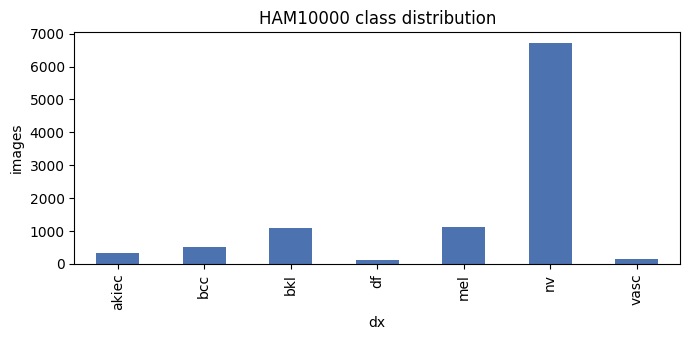

In [3]:
counts = df["dx"].value_counts().reindex(CLASSES)
display(pd.DataFrame({"images": counts, "percent": (100*counts/len(df)).round(2)}))
ax = counts.plot.bar(color="#4C72B0", figsize=(7,3.5), title="HAM10000 class distribution")
ax.set_ylabel("images"); plt.tight_layout(); plt.savefig(f"{OUT}/class_distribution.png", dpi=150); plt.show()

## Step 4 — Leak-free split (SABSE IMPORTANT step)
HAM10000 me **ek hi lesion ki kai photos** hain (same `lesion_id`). Agar random split kiya to same lesion train aur test dono me aa jayega → model "yaad" kar lega → fake high accuracy (90%+).

Isliye `StratifiedGroupKFold` use karte hain — **group = lesion_id**, stratify = class.
1. Pehle ~1/7 lesions ko **test set** ke liye alag rakh do (kabhi training me use nahi hoga).
2. Bache hue data par **5-fold CV** (paper jaisa) → ek fold validation, baaki 4 train.

> Note: paper ne official ISIC 2018 test set (1,511 images) use kiya tha; uska ground truth request par milta hai. Hum HAM10000 ka lesion-grouped hold-out use kar rahe hain — **ye difference Limitations me likhna**.

In [4]:
sgkf = StratifiedGroupKFold(n_splits=CFG["test_frac_splits"], shuffle=True, random_state=CFG["seed"])
trval_idx, test_idx = next(sgkf.split(df, df["label"], groups=df["lesion_id"]))
df["split"] = "trainval"; df.loc[test_idx, "split"] = "test"

trval = df[df.split == "trainval"].reset_index()
cv = StratifiedGroupKFold(n_splits=CFG["n_folds"], shuffle=True, random_state=CFG["seed"])
df["fold"] = -1
for f, (_, va) in enumerate(cv.split(trval, trval["label"], groups=trval["lesion_id"])):
    df.loc[trval.loc[va, "index"].values, "fold"] = f

# leakage check: koi lesion do splits me nahi hona chahiye
assert not set(df[df.split=="test"].lesion_id) & set(df[df.split=="trainval"].lesion_id), "LEAK!"
df[["image_id","lesion_id","dx","split","fold"]].to_csv(f"{OUT}/splits.csv", index=False)

print(pd.crosstab(df["dx"], [df["split"]]).reindex(CLASSES))
print("\nVal images per fold:", df[df.split=="trainval"].fold.value_counts().sort_index().tolist())

split  test  trainval
dx                   
akiec    34       293
bcc      89       425
bkl     168       931
df        9       106
mel     146       967
nv      974      5731
vasc     21       121

Val images per fold: [1735, 1715, 1698, 1730, 1696]


## Step 5 — Images RAM me cache karo (speed trick)
Original images 600×450 hain; har epoch me 10k JPEG decode karna slow hai (Kaggle me sirf 4 CPU). Ek baar 320×240 me resize karke RAM me rakh lete hain (~2.3 GB). Accuracy par koi farak nahi kyunki training 224 par hi hoti hai. ~2–4 min lagega.

In [5]:
def load_resized(p, side=CFG["cache_side"]):
    im = Image.open(p).convert("RGB")
    w, h = im.size; s = side / max(w, h)
    return np.asarray(im.resize((round(w*s), round(h*s)), Image.BILINEAR))

t0 = time.time()
from concurrent.futures import ThreadPoolExecutor
with ThreadPoolExecutor(8) as ex:
    CACHE = list(ex.map(load_resized, df["path"].tolist()))
print(f"Cached {len(CACHE)} images in {time.time()-t0:.0f}s | shape example {CACHE[0].shape}")

Cached 10015 images in 35s | shape example (240, 320, 3)


## Step 6 — Augmentation + Dataset (paper ke exact rules)
**Train:** random crop → 224, random 90° rotation, horizontal/vertical flip, halka color/contrast/saturation/hue jitter. Paper ne **mean-pixel normalization nahi** kiya — isliye hum bhi sirf `ToTensor()` (0–1 scale) karte hain.

**Test/Val:** image ka 80% center crop → 224. Plus **TTA** (test-time augmentation): horizontal flip × rotation 0°/90° = 4 versions ka average (Step 10 me).

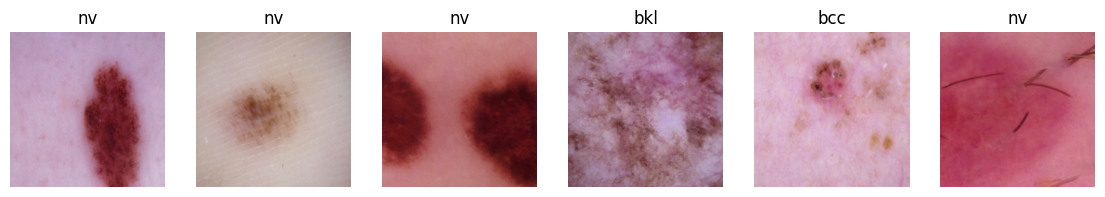

In [6]:
class RandomRot90:
    def __call__(self, x): return x.rotate(90 * random.randint(0, 3), expand=True)

class CenterCropFrac:
    def __init__(self, frac): self.frac = frac
    def __call__(self, x):
        w, h = x.size
        return T.functional.center_crop(x, (int(h*self.frac), int(w*self.frac)))

S = CFG["img_size"]
train_tf = T.Compose([
    T.RandomResizedCrop(S, scale=(0.4, 1.0), ratio=(0.75, 1.333)),
    RandomRot90(), T.RandomHorizontalFlip(), T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
    T.ToTensor(),                    # NO mean normalization (as in paper)
])
eval_tf = T.Compose([CenterCropFrac(0.8), T.Resize((S, S)), T.ToTensor()])

class HamDS(Dataset):
    def __init__(self, idx, tf): self.idx, self.tf = list(idx), tf
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        j = self.idx[i]
        return self.tf(Image.fromarray(CACHE[j])), int(df.at[j, "label"])

def make_loaders(fold):
    tr = df.index[(df.split=="trainval") & (df.fold != fold)]
    va = df.index[(df.split=="trainval") & (df.fold == fold)]
    te = df.index[df.split=="test"]
    kw = dict(num_workers=CFG["num_workers"], pin_memory=True)
    return (DataLoader(HamDS(tr, train_tf), CFG["batch_size"], shuffle=True, drop_last=True, **kw),
            DataLoader(HamDS(va, eval_tf), 64, **kw),
            DataLoader(HamDS(te, eval_tf), 64, **kw), tr, va, te)

# sanity: augmented samples dekh lo
tl, *_ = make_loaders(CFG["fold"])
xb, yb = next(iter(tl))
fig, axs = plt.subplots(1, 6, figsize=(14, 2.6))
for a, x, y in zip(axs, xb, yb):
    a.imshow(x.permute(1,2,0)); a.set_title(CLASSES[y]); a.axis("off")
plt.show()

## Step 7 — Model, loss, optimizer (paper recipe)
- **ResNet34**, ImageNet weights, last layer → 7 classes
- **Weighted cross-entropy** — rare classes (DF, VASC) ko zyada weight, taaki model NV par bias na ho. Weight = `N / (K × count_c)` (train set se).
- **Adam**, LR 1e-4, `ReduceLROnPlateau` (×0.1 jab val loss 3 epochs tak na sudhre, min 1e-9)

In [7]:
def build_model():
    m = getattr(torchvision.models, CFG["arch"])(weights="IMAGENET1K_V1")
    m.fc = nn.Linear(m.fc.in_features, len(CLASSES))
    return m

def class_weights(train_idx):
    cnt = np.bincount(df.loc[train_idx, "label"], minlength=len(CLASSES))
    w = len(train_idx) / (len(CLASSES) * cnt)
    return torch.tensor(w, dtype=torch.float32)

print("Params (M):", sum(p.numel() for p in build_model().parameters())/1e6)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 214MB/s]


Params (M): 21.288263


## Step 8 — Training loop
Har epoch ke baad: train loss, val loss, val accuracy, **val mean recall**, LR aur time print hota hai. Jis epoch par **val loss sabse kam** ho wo model save hota hai (paper: *"best performing network on the hold-out validation set"*). Val loss 10 epochs tak na sudhre to **early stop**.

Epoch-wise time print hoga — yahi number report me "training time" ke liye use karna (GPU type ke saath).

In [8]:
@torch.no_grad()
def predict(model, loader, tta=False):
    model.eval(); P, Y = [], []
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        with torch.autocast(DEVICE.type, enabled=CFG["use_amp"] and DEVICE.type=="cuda"):
            if tta:   # hflip x rot{0,90}  -> 4 views (paper's minor TTA)
                views = [x, torch.flip(x, [3]), torch.rot90(x, 1, [2, 3]), torch.rot90(torch.flip(x, [3]), 1, [2, 3])]
                logits = torch.stack([model(v).float() for v in views]).mean(0)
            else:
                logits = model(x).float()
        P.append(logits.cpu()); Y.append(y)
    return torch.cat(P), torch.cat(Y)

def train_fold(fold):
    seed_everything(CFG["seed"] + fold)
    tl, vl, testl, tr, va, te = make_loaders(fold)
    model = build_model().to(DEVICE)
    if torch.cuda.device_count() > 1: model = nn.DataParallel(model)
    w = class_weights(tr).to(DEVICE)
    crit = nn.CrossEntropyLoss(weight=w)
    opt = torch.optim.Adam(model.parameters(), lr=CFG["lr"])
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=CFG["lr_factor"],
                                                       patience=CFG["lr_patience"], min_lr=CFG["min_lr"])
    scaler = torch.amp.GradScaler(enabled=CFG["use_amp"] and DEVICE.type=="cuda")
    best, bad, hist, ckpt = 1e9, 0, [], f"{OUT}/best_fold{fold}.pt"
    print(f"Fold {fold}: train={len(tr)} val={len(va)} test={len(te)} | class weights={np.round(w.cpu().numpy(),2)}")
    t_start = time.time()
    for ep in range(1, CFG["max_epochs"] + 1):
        model.train(); t0 = time.time(); tot, n = 0.0, 0
        for x, y in tl:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(DEVICE.type, enabled=CFG["use_amp"] and DEVICE.type=="cuda"):
                loss = crit(model(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            tot += loss.item() * len(y); n += len(y)
        logits, yv = predict(model, vl)
        vloss = F.cross_entropy(logits, yv, weight=w.cpu()).item()
        pv = logits.argmax(1).numpy()
        row = dict(epoch=ep, train_loss=tot/n, val_loss=vloss,
                   val_acc=accuracy_score(yv, pv), val_mean_recall=balanced_accuracy_score(yv, pv),
                   lr=opt.param_groups[0]["lr"], sec=time.time()-t0)
        hist.append(row); sched.step(vloss)
        flag = ""
        if vloss < best:
            best, bad, flag = vloss, 0, "  <- best, saved"
            torch.save((model.module if hasattr(model, "module") else model).state_dict(), ckpt)
        else:
            bad += 1
        print(f"ep {ep:3d} | tr_loss {row['train_loss']:.4f} | val_loss {vloss:.4f} | val_acc {row['val_acc']:.3f} "
              f"| val_mean_recall {row['val_mean_recall']:.3f} | lr {row['lr']:.0e} | {row['sec']:.0f}s{flag}")
        if bad >= CFG["early_stop_patience"]:
            print(f"Early stopping at epoch {ep} (best val_loss {best:.4f})"); break
    total_min = (time.time() - t_start) / 60
    gpu = torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "CPU"
    print(f"\nTotal training time: {total_min:.1f} min on {gpu} | epochs run: {ep}")
    pd.DataFrame(hist).to_csv(f"{OUT}/history_fold{fold}.csv", index=False)
    return ckpt, pd.DataFrame(hist), dict(total_min=total_min, epochs=ep, gpu=gpu)

ckpt, hist, train_info = train_fold(CFG["fold"])

Fold 0: train=6839 val=1735 test=1441 | class weights=[ 4.09  3.12  1.37 10.74  1.26  0.21  9.39]
ep   1 | tr_loss 1.2692 | val_loss 0.9345 | val_acc 0.621 | val_mean_recall 0.714 | lr 1e-04 | 73s  <- best, saved
ep   2 | tr_loss 0.9331 | val_loss 0.8596 | val_acc 0.624 | val_mean_recall 0.728 | lr 1e-04 | 60s  <- best, saved
ep   3 | tr_loss 0.8345 | val_loss 0.9478 | val_acc 0.701 | val_mean_recall 0.711 | lr 1e-04 | 60s
ep   4 | tr_loss 0.7573 | val_loss 0.7720 | val_acc 0.719 | val_mean_recall 0.741 | lr 1e-04 | 60s  <- best, saved
ep   5 | tr_loss 0.7179 | val_loss 0.9193 | val_acc 0.701 | val_mean_recall 0.697 | lr 1e-04 | 61s
ep   6 | tr_loss 0.6436 | val_loss 0.8205 | val_acc 0.672 | val_mean_recall 0.757 | lr 1e-04 | 61s
ep   7 | tr_loss 0.6530 | val_loss 0.7960 | val_acc 0.681 | val_mean_recall 0.706 | lr 1e-04 | 61s
ep   8 | tr_loss 0.5949 | val_loss 0.7351 | val_acc 0.715 | val_mean_recall 0.715 | lr 1e-04 | 61s  <- best, saved
ep   9 | tr_loss 0.5989 | val_loss 0.7585 | va

## Step 9 — Learning curves (report Figure)

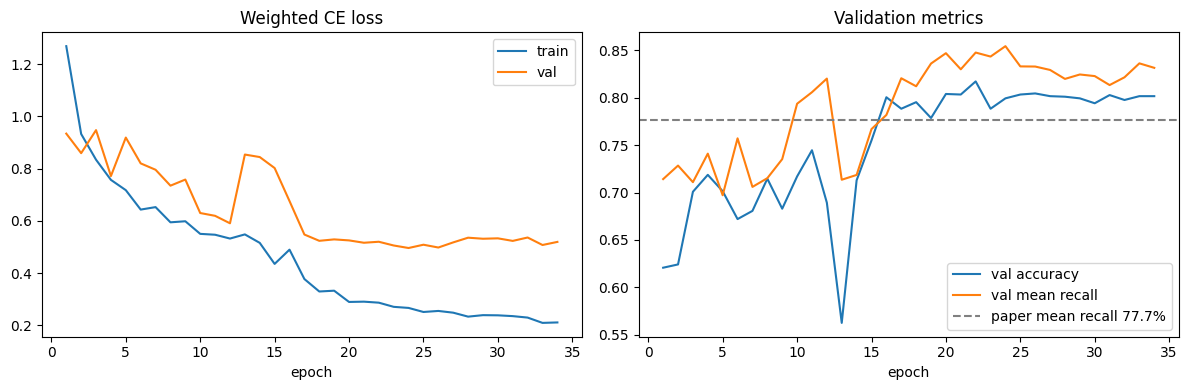

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist.epoch, hist.train_loss, label="train"); ax[0].plot(hist.epoch, hist.val_loss, label="val")
ax[0].set_title("Weighted CE loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(hist.epoch, hist.val_acc, label="val accuracy"); ax[1].plot(hist.epoch, hist.val_mean_recall, label="val mean recall")
ax[1].axhline(0.777, ls="--", c="gray", label="paper mean recall 77.7%")
ax[1].set_title("Validation metrics"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.savefig(f"{OUT}/learning_curves.png", dpi=150); plt.show()

## Step 10 — Final evaluation on held-out TEST set (yahi M2 ka result hai)
Best checkpoint load karke **TTA** ke saath test set par predict karte hain. Brief ke rule ke hisaab se sirf accuracy nahi — ye sab report hota hai:
- Accuracy, **mean recall** (+ bootstrap 95% CI, paper jaisa)
- Per-class **sensitivity (recall)**, specificity, precision, F1, **AUC**
- Macro AUC (one-vs-rest)
- **Malignant vs benign** (akiec+bcc+mel): sensitivity, specificity, AUC
- Confusion matrix

In [10]:
model = build_model().to(DEVICE); model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
_, _, test_loader, *_ = make_loaders(CFG["fold"])
logits_te, y_te = predict(model, test_loader, tta=True)
prob = F.softmax(logits_te, 1).numpy(); y = y_te.numpy(); pred = prob.argmax(1)

acc, mrec = accuracy_score(y, pred), balanced_accuracy_score(y, pred)
macro_auc = roc_auc_score(y, prob, multi_class="ovr", average="macro")

rng = np.random.default_rng(0); boots = []
for _ in range(1000):
    b = rng.integers(0, len(y), len(y))
    if len(np.unique(y[b])) == len(CLASSES): boots.append(balanced_accuracy_score(y[b], pred[b]))
lo, hi = np.percentile(boots, [2.5, 97.5])

cm = confusion_matrix(y, pred, labels=range(len(CLASSES)))
rows = []
for i, c in enumerate(CLASSES):
    tp = cm[i, i]; fn = cm[i].sum() - tp; fp = cm[:, i].sum() - tp; tn = cm.sum() - tp - fn - fp
    rows.append(dict(cls=c, n=int(cm[i].sum()), sensitivity=tp/(tp+fn), specificity=tn/(tn+fp),
                     precision=tp/max(tp+fp, 1), f1=2*tp/max(2*tp+fp+fn, 1),
                     auc=roc_auc_score((y==i).astype(int), prob[:, i])))
per_class = pd.DataFrame(rows).set_index("cls").round(3)

mal_idx = [cls2idx[c] for c in MALIGNANT]
y_mal = np.isin(y, mal_idx).astype(int); p_mal = prob[:, mal_idx].sum(1)
pred_mal = np.isin(pred, mal_idx).astype(int)
mal = dict(sensitivity=recall_score(y_mal, pred_mal), specificity=recall_score(1-y_mal, 1-pred_mal),
           auc=roc_auc_score(y_mal, p_mal))

print(f"TEST images: {len(y)}")
print(f"Accuracy      : {acc:.3f}   (paper 0.803)")
print(f"Mean recall   : {mrec:.3f}   95% CI [{lo:.3f}, {hi:.3f}]   (paper 0.777, CI 0.703-0.851)")
print(f"Macro AUC     : {macro_auc:.3f}")
print(f"Malignant vs benign -> sens {mal['sensitivity']:.3f} | spec {mal['specificity']:.3f} | AUC {mal['auc']:.3f}")
display(per_class)

comp = pd.DataFrame({"Paper (ISIC-2018 test)": [0.803, 0.777, None],
                     "Ours (HAM10000 grouped hold-out)": [round(acc,3), round(mrec,3), round(macro_auc,3)]},
                    index=["Accuracy", "Mean recall", "Macro AUC"])
display(comp)

TEST images: 1441
Accuracy      : 0.801   (paper 0.803)
Mean recall   : 0.787   95% CI [0.732, 0.834]   (paper 0.777, CI 0.703-0.851)
Macro AUC     : 0.964
Malignant vs benign -> sens 0.844 | spec 0.868 | AUC 0.937


,n,sensitivity,specificity,precision,f1,auc
cls,,,,,,
akiec,34,0.676,0.981,0.460,0.548,0.953
bcc,89,0.865,0.984,0.786,0.824,0.986
bkl,168,0.756,0.954,0.686,0.720,0.958
df,9,0.778,0.997,0.583,0.667,0.997
mel,146,0.658,0.893,0.410,0.505,0.895
nv,974,0.825,0.936,0.964,0.889,0.964
vasc,21,0.952,0.994,0.714,0.816,0.999


,Paper (ISIC-2018 test),Ours (HAM10000 grouped hold-out)
Accuracy,0.803,0.801
Mean recall,0.777,0.787
Macro AUC,NaN,0.964


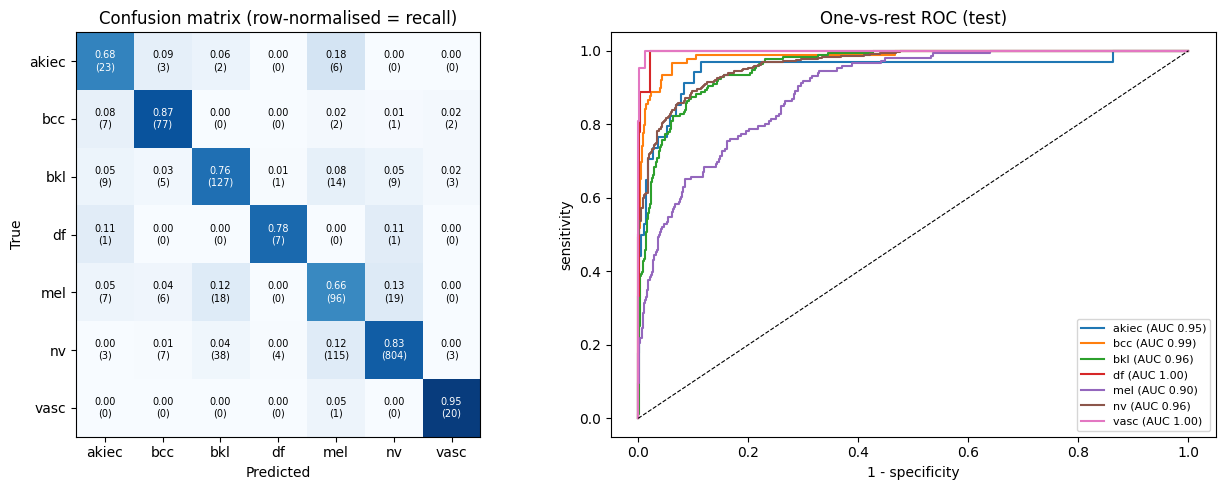

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
cmn = cm / cm.sum(1, keepdims=True)
im = ax[0].imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ax[0].set_xticks(range(7), CLASSES); ax[0].set_yticks(range(7), CLASSES)
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("True"); ax[0].set_title("Confusion matrix (row-normalised = recall)")
for i in range(7):
    for j in range(7):
        ax[0].text(j, i, f"{cmn[i,j]:.2f}\n({cm[i,j]})", ha="center", va="center", fontsize=7,
                   color="white" if cmn[i,j] > .5 else "black")
for i, c in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve((y==i).astype(int), prob[:, i])
    ax[1].plot(fpr, tpr, label=f"{c} (AUC {per_class.loc[c,'auc']:.2f})")
ax[1].plot([0,1],[0,1],"k--",lw=.8); ax[1].set_xlabel("1 - specificity"); ax[1].set_ylabel("sensitivity")
ax[1].set_title("One-vs-rest ROC (test)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUT}/confusion_roc.png", dpi=150); plt.show()

## Step 11 — Calibration baseline (M3 ke liye zaroori measurement)
Paper ka core finding: doctors AI ki **probabilities** dekh kar decision badalte hain. To probabilities kitni *trustworthy* hain? Ye **ECE (Expected Calibration Error)** aur reliability diagram se dikhta hai.

Ye sirf **measurement** hai, koi change nahi — M3 hypothesis (jaise temperature scaling) ka baseline yahi number banega.

ECE = 0.0623 | NLL = 0.5301 | mean top-1 confidence = 0.858 vs accuracy = 0.801


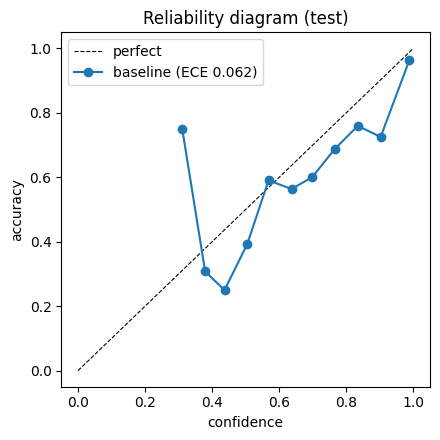

In [12]:
def ece_score(prob, y, n_bins=15):
    conf = prob.max(1); correct = (prob.argmax(1) == y)
    bins = np.linspace(0, 1, n_bins + 1); ece = 0; xs, ys, ns = [], [], []
    for a, b in zip(bins[:-1], bins[1:]):
        m = (conf > a) & (conf <= b)
        if m.sum():
            ece += m.mean() * abs(correct[m].mean() - conf[m].mean())
            xs.append(conf[m].mean()); ys.append(correct[m].mean()); ns.append(m.sum())
    return ece, xs, ys

ece, xs, ys = ece_score(prob, y)
nll = F.cross_entropy(torch.log(torch.tensor(prob) + 1e-12), torch.tensor(y), reduction="mean").item()
print(f"ECE = {ece:.4f} | NLL = {nll:.4f} | mean top-1 confidence = {prob.max(1).mean():.3f} vs accuracy = {acc:.3f}")
plt.figure(figsize=(4.5, 4.5))
plt.plot([0,1],[0,1],"k--",lw=.8,label="perfect"); plt.plot(xs, ys, "o-", label=f"baseline (ECE {ece:.3f})")
plt.xlabel("confidence"); plt.ylabel("accuracy"); plt.title("Reliability diagram (test)"); plt.legend()
plt.tight_layout(); plt.savefig(f"{OUT}/reliability_baseline.png", dpi=150); plt.show()

## Step 12 — Grad-CAM (paper ka explainability finding check karo)
Paper ne dikhaya tha ki **AKIEC** predict karte waqt CNN lesion ke *bahar* (sun-damaged background skin) zyada dekhta hai. Har class ka ek test example + uska Grad-CAM — report ka qualitative figure.

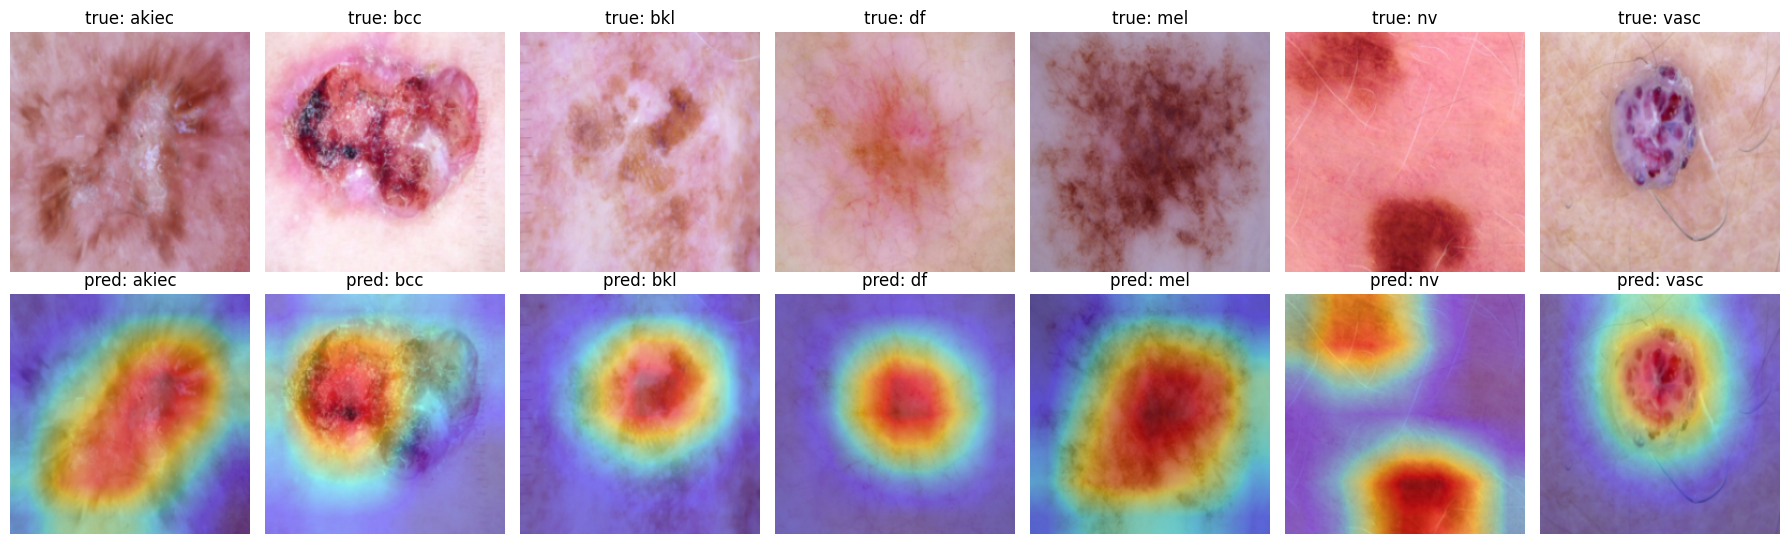

In [13]:
class GradCAM:
    def __init__(self, m, layer):
        self.m, self.a, self.g = m, None, None
        layer.register_forward_hook(lambda _, __, o: setattr(self, "a", o))
        layer.register_full_backward_hook(lambda _, __, go: setattr(self, "g", go[0]))
    def __call__(self, x, cls=None):
        self.m.eval(); x = x.requires_grad_(True); out = self.m(x)
        cls = out.argmax(1).item() if cls is None else cls
        self.m.zero_grad(); out[0, cls].backward()
        w = self.g.mean((2, 3), keepdim=True); cam = F.relu((w * self.a).sum(1)).squeeze().detach()
        cam = F.interpolate(cam[None, None], x.shape[-2:], mode="bilinear")[0, 0]
        return ((cam - cam.min()) / (cam.max() - cam.min() + 1e-8)).cpu().numpy(), cls

gc = GradCAM(model, model.layer4)
te_idx = df.index[df.split == "test"]
fig, axs = plt.subplots(2, 7, figsize=(18, 5.5))
for k, c in enumerate(CLASSES):
    j = df.loc[te_idx][df.loc[te_idx, "dx"] == c].index[0]
    x = eval_tf(Image.fromarray(CACHE[j]))[None].to(DEVICE)
    cam, pc = gc(x.float())
    img = x[0].detach().permute(1, 2, 0).cpu().numpy()
    axs[0, k].imshow(img); axs[0, k].set_title(f"true: {c}"); axs[0, k].axis("off")
    axs[1, k].imshow(img); axs[1, k].imshow(cam, cmap="jet", alpha=.45)
    axs[1, k].set_title(f"pred: {CLASSES[pc]}"); axs[1, k].axis("off")
plt.tight_layout(); plt.savefig(f"{OUT}/gradcam.png", dpi=150); plt.show()

## Step 13 — Sab kuch save karo
`/kaggle/working/` me ye files banti hain (Output tab se download karo):
- `best_fold0.pt` — model weights (M4 me reuse)
- `test_predictions.csv` — har test image ki 7 probabilities (**M3/M4 temperature scaling isi par chalega, retrain ki zaroorat nahi**)
- `val_logits.csv` — validation logits (temperature *yahi fit hota hai*, test par nahi)
- `metrics.json`, `per_class_metrics.csv`, `history_fold0.csv`, `splits.csv`
- Figures: class distribution, learning curves, confusion+ROC, reliability, Grad-CAM

In [14]:
pd.DataFrame(prob, columns=[f"p_{c}" for c in CLASSES]).assign(
    image_id=df.loc[te_idx, "image_id"].values, y_true=[CLASSES[i] for i in y], y_pred=[CLASSES[i] for i in pred]
).to_csv(f"{OUT}/test_predictions.csv", index=False)

_, val_loader, *_ = make_loaders(CFG["fold"])
lv, yv = predict(model, val_loader, tta=True)
pd.DataFrame(lv.numpy(), columns=[f"logit_{c}" for c in CLASSES]).assign(y_true=yv.numpy()).to_csv(
    f"{OUT}/val_logits.csv", index=False)
pd.DataFrame(logits_te.numpy(), columns=[f"logit_{c}" for c in CLASSES]).assign(y_true=y).to_csv(
    f"{OUT}/test_logits.csv", index=False)

per_class.to_csv(f"{OUT}/per_class_metrics.csv")
metrics = dict(fold=CFG["fold"], n_test=int(len(y)), accuracy=acc, mean_recall=mrec,
               mean_recall_ci95=[lo, hi], macro_auc=macro_auc, malignant=mal, ece=ece, nll=nll,
               train_info=train_info, config=CFG,
               paper=dict(accuracy=0.803, mean_recall=0.777, mean_recall_ci95=[0.703, 0.851]))
json.dump(metrics, open(f"{OUT}/metrics.json", "w"), indent=2, default=float)
print(json.dumps({k: metrics[k] for k in ["accuracy", "mean_recall", "macro_auc", "ece"]}, indent=2, default=float))
print("\nSaved files:", sorted(os.listdir(OUT)))

{
  "accuracy": 0.8008327550312283,
  "mean_recall": 0.7872494996525597,
  "macro_auc": 0.9644597097727868,
  "ece": 0.062345648912155834
}

Saved files: ['__notebook__.ipynb', 'best_fold0.pt', 'class_distribution.png', 'confusion_roc.png', 'gradcam.png', 'history_fold0.csv', 'learning_curves.png', 'metrics.json', 'per_class_metrics.csv', 'reliability_baseline.png', 'splits.csv', 'test_logits.csv', 'test_predictions.csv', 'val_logits.csv']


## (Optional) Step 14 — Baaki 4 folds (5-fold CV, paper jaisa)
M2 ke liye 1 fold kaafi hai. Time ho to ye cell chalao (~4–6 ghante total) — phir mean ± std report kar sakte ho, jo zyada strong result hai. Kaggle ki 12-hour session limit ke andar aa jata hai; **Save & Run All (Commit)** se chalao.

In [15]:
RUN_ALL_FOLDS = False
if RUN_ALL_FOLDS:
    res = []
    for f in range(CFG["n_folds"]):
        if f == CFG["fold"]:
            res.append(dict(fold=f, mean_recall=mrec, accuracy=acc, auc=macro_auc)); continue
        ck, _, _ = train_fold(f)
        m = build_model().to(DEVICE); m.load_state_dict(torch.load(ck, map_location=DEVICE))
        lg, yy = predict(m, test_loader, tta=True); pp = F.softmax(lg, 1).numpy(); yy = yy.numpy()
        res.append(dict(fold=f, mean_recall=balanced_accuracy_score(yy, pp.argmax(1)),
                        accuracy=accuracy_score(yy, pp.argmax(1)),
                        auc=roc_auc_score(yy, pp, multi_class="ovr")))
    r = pd.DataFrame(res); display(r); print(r.describe().loc[["mean", "std"]])
    r.to_csv(f"{OUT}/cv_results.csv", index=False)